# Import thư viện và load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.preprocessing import load_raw_data, clean_domain_bounds

# 1. Load Data thô
df_raw = load_raw_data('../data/raw/house_buying_dec29th_2025.csv')
print(f"Kích thước ban đầu: {df_raw.shape}")

Kích thước ban đầu: (66912, 11)


# Data cleaning

In [2]:
# Áp dụng lọc sạch miền giá trị (Domain Filtering) không bị rò rỉ dữ liệu
df_clean = clean_domain_bounds(df_raw)
print(f"Kích thước sau khi dọn dẹp: {df_clean.shape}")

Kích thước sau khi dọn dẹp: (45857, 8)


# Trực quan hóa dữ liệu sau khi đã dọn dẹp

Đã loại bỏ 21,055 dòng dữ liệu lỗi/outlier/missing target.
Bảng so sánh Dữ liệu thiếu (Missing Values):


,Missing (Before),Missing (After)
area_m2,16568,0.0
bathrooms,15364,7490.0
bedrooms,11639,4822.0
detail_url,7,NaN
floors,14634,9592.0
price_million_vnd,2103,0.0


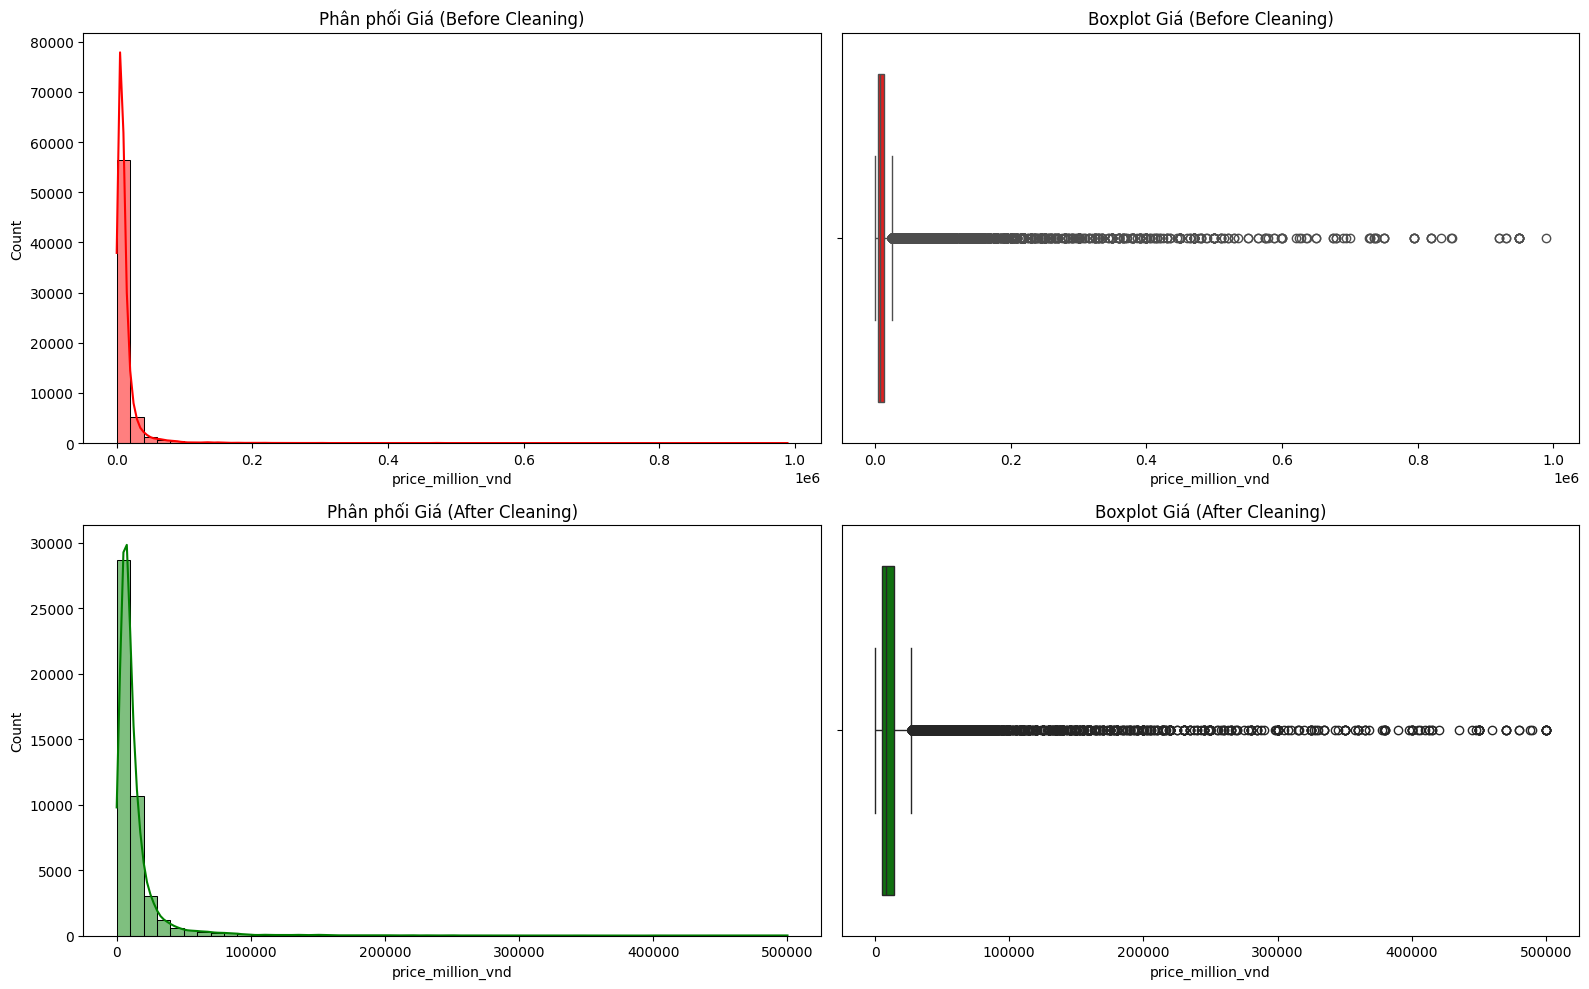

In [3]:
print(f"Đã loại bỏ {len(df_raw) - len(df_clean):,} dòng dữ liệu lỗi/outlier/missing target.")

# Bảng so sánh Missing Values
missing_comparison = pd.DataFrame({
    'Missing (Before)': df_raw.isnull().sum(),
    'Missing (After)': df_clean.isnull().sum()
})
print("Bảng so sánh Dữ liệu thiếu (Missing Values):")
display(missing_comparison[missing_comparison['Missing (Before)'] > 0])

# Trực quan hóa Outlier Before vs After
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Before Cleaning
sns.histplot(df_raw['price_million_vnd'], bins=50, kde=True, color='red', ax=axes[0, 0])
axes[0, 0].set_title('Phân phối Giá (Before Cleaning)')

sns.boxplot(x=df_raw['price_million_vnd'], color='red', ax=axes[0, 1])
axes[0, 1].set_title('Boxplot Giá (Before Cleaning)')

# After Cleaning
sns.histplot(df_clean['price_million_vnd'], bins=50, kde=True, color='green', ax=axes[1, 0])
axes[1, 0].set_title('Phân phối Giá (After Cleaning)')

sns.boxplot(x=df_clean['price_million_vnd'], color='green', ax=axes[1, 1])
axes[1, 1].set_title('Boxplot Giá (After Cleaning)')

plt.tight_layout()
plt.show()

# 5. Lưu dữ liệu đã làm sạch
os.makedirs('../data/processed', exist_ok=True)
df_clean.to_csv('../data/processed/housing_clean.csv', index=False)

Đánh giá hiệu quả làm sạch dữ liệu:

* Khắc phục triệt để lỗi nhập liệu: Biểu đồ đỏ cho thấy các mức giá ảo lên tới 1.000.000 (1.000 tỷ VNĐ) đã bóp méo hoàn toàn đồ thị. Biểu đồ xanh xác nhận dải nhiễu này đã bị cắt bỏ, đưa mức giá tối đa về ngưỡng thực tế (dưới 500 tỷ VNĐ).

* Phục hồi dải phân vị lõi (IQR): Hộp Boxplot chứa 50% lượng dữ liệu trung tâm từ chỗ bị ép xẹp thành một đường thẳng (do outlier kéo giãn trục) nay đã hiển thị rõ ràng cấu trúc thống kê.

* Trả lại phân phối thực tế của thị trường: Histogram xanh lá thể hiện rõ đặc tính lệch phải (right-skewed) tự nhiên của giá bất động sản, với phần lớn lượng giao dịch tập trung ở phân khúc giá thấp và trung bình.

* Bảo toàn "True Outliers": Các điểm tròn còn sót lại ở Boxplot xanh là những bất động sản siêu sang thực tế, không phải dữ liệu rác. Việc giữ lại chúng đảm bảo mô hình Linear Regression không bị bẻ cong bởi lỗi nhập liệu, nhưng vẫn học được quy luật giá của phân khúc cao cấp.